# Grover's search - Part 2
**Writing the code** 

In this tutorial, we will continue developing Grover's search algorithm for solving Boolean satisfiability (SAT) problems using QDE tools. 
In part 1 of this series we defined the high-level structure of Grover's algorithm, looked at implementing the marking oracle for an example SAT formula, and designed circuits for both.
Now, we will implement this algorithm using Workbench and test our code.

## 1. Implement logical AND and OR

Let's start with the simplest building blocks of the marking oracle for the SAT problems: implementing logical operations AND and OR as reversible computations.
The code will be very simple, but it will showcase several Workbench tools not covered in the previous tutorial:

* Filter pipeline - a way to configure how a program is executed
* Using a specialized simulator, `>>bit-sim>>`, to run programs
* Applying a primitive gate to each qubit in a quantum register
* Applying simple controlled gates

As usual, we start our program by defining a QPU object that we'll use to run the code.
QPU objects specify the _filter pipeline_ - a sequence of tools (filters) that process the QPU instructions such as gates and measurements.
The default constructor `QPU()` we used in the previous tutorial creates a QPU with two filters:

1. `>>state-vector-sim>>` filter that runs state vector simulation of the program.
2. `>>buffer>>` filter that gives us access to the list of QPU instructions, for example, to draw a circuit executed by the program.

This time, our program is going to use only a limited set of gates - $X$ gates and their controlled variants - so we can use a specialized filter, `>>bit-sim>>`, to simulate it. This filter works only with basis states and is well-suited for simulating quantum computations that implement classical ones, such as arithmetic or, in our case, logic operations that comprise marking oracles. We'll also need the `>>buffer>>` filter to draw circuits. This is a commonly used filter pipeline, so we can use a filter preset `BIT_DEFAULT` to specify it. We can create the QPU by passing the right filter preset and the number of qubits as the arguments:

```python
    qpu = QPU(filters=BIT_DEFAULT, num_qubits=5)
```

Once we've created the QPU, we can allocate three qubit registers: `a` to act as the input to the logic operations, and `b` and `c` to act as the output for AND and OR operations, respectively. Then, we initialize the input register to a non-zero basis state using the `write` method. This method takes an integer and initializes the qubit register to the basis state encoded by this integer in little-endian notation (least significant bit stored first). For example, the integer $6 = 0b110$ is `110` in binary notation, so the following command will set the register `a` to the state $|011\rangle$:

```python
    a.write(0b110)
```

Now, we are ready to implement the AND and OR logical operations as sequences of quantum gates in our program. 

AND of several Boolean values is true if and only if all values are true. In terms of quantum gates, we need to flip the state of the target qubit if all input qubits are in the $|1\rangle$ state; we can do that using a controlled $X$ gate. 

To apply a gate to a qubit register in Workbench, we call an appropriate method of the object that represents that register. For example, we can apply an $X$ gate to register `b` using the method `x`:

```python
    b.x()
```

To apply a controlled gate to a register, we can use the same method as for the uncontrolled gate with an additional argument that specifies the control register. For example, we can apply a controlled-$X$ gate with register `a` as control and register `b` as target by calling a method `b.x` and passing register `a` as the argument `cond` (the argument `cond` means "conditioned on"):

```python
    b.x(cond=a)
```

OR of several Boolean values is true if and only if at least one of the values is true. In other words, it is always true, unless all the values are false.
In terms of quantum gates, we can evaluate OR in two steps:

1. Flip the state of the target qubit if all input qubits are in the $|0\rangle$ states.
2. Flip the state of the target qubit using an $X$ gate.

If we want to use the register `c` as the target for our OR operation, we need to add the following gates to our circuit:

1. An $X$ gate using the _negation_ of the register `a` as the control. The `~` operator inverts the control logic, that is, this gate applies the $X$ gate to the register `c` only if all qubits of the register `a` are in the $|0\rangle$ state.
2. An $X$ gate without conditions.

```python
    c.x(cond=~a)
    c.x()
```

Finally, we need to get the results of evaluating AND and OR on our input `110`. Since we are using a simulator that doesn't support superposition states, we can simply measure the target qubits `b` and `c` and print the results:

```python
    print(f"AND(110) = {b.read()}")
    print(f"OR(110) = {c.read()}")
```

AND(110) = 0
OR(110) = 1


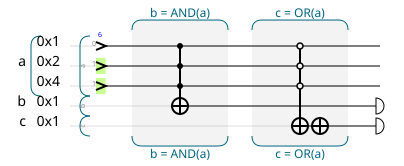

In [1]:
from psiqworkbench import QPU, Qubits
from psiqworkbench.filter_presets import BIT_DEFAULT

# Define a QPU instance to run the program on
qpu = QPU(filters=BIT_DEFAULT, num_qubits=5)

# Allocate qubits to act as inputs and outputs of AND and OR gates
a = Qubits(3, "a", qpu)
b = Qubits(1, "b", qpu)
c = Qubits(1, "c", qpu)

# Initialize the input qubits
a.write(0b110)
qpu.nop()

# Calculate AND of the qubits in a and store result in b
qpu.label("b = AND(a)")
b.x(cond=a)
qpu.label("")
qpu.nop()

# Calculate OR of the qubits in a and store result in c
qpu.label("c = OR(a)")
qpu.nop()
c.x(cond=~a)
c.x()
qpu.label("")
qpu.nop()

# Read out the results
print(f"AND(110) = {b.read()}")
print(f"OR(110) = {c.read()}")

qpu.draw()

## 2. Test reversible computations

In the previous code snippet, we checked that our implementation of AND/OR operations was correct by running it on one basis state and printing the results. 
This approach is, of course, insufficient when validating non-trivial reversible computations such as arithmetic or even evaluation of larger Boolean expressions.
Let's see how to write tests for reversible computations in general using Workbench tools. 

Reversible computations implement classical computations and are defined based on the required results on the basis states. If the code gives the correct results on all basis states and doesn't use measurements or gates other than $X$ and controlled $X$, it will produce correct results on all superposition states as well. 
This means that for reversible computations, we can test the code only on the basis states. The `>>bit-sim>>` filter is perfectly suited for this, since it's much faster than the state vector simulator and can handle quantum programs with orders of magnitude more qubits.

If our program is small enough (uses relatively few qubits) such that going through all basis states is very fast, we can verify our program exhaustively. For larger programs, we have to test them on a subset of basis states. In either case, the test for a single basis state looks as follows:

1. Prepare the input quantum register in the given basis state.  
    If the given basis state is represented as an integer (for example, if we're iterating through all basis states in a for loop), we can either use the `write` method with this integer as the argument or use the `x` gate with this integer as the `tgt_bits` argument. Freshly allocated qubits start in the $|0\rangle$ state, so for them both methods will do the same: set the qubits that correspond to the bits of the integer that equal $1$ to the $|1\rangle$ state and leave others in the $|0\rangle$ state.
2. Run the quantum computation we want to test on this register.  
    If the code uses gates other than $X$ and its controlled variants, the `>>bit-sim>>` filter will raise an exception here.
3. Check that the results match those of the classical computation.  
    If the classical computation is implemented "in-place", that is, is expected to modify the input register to store the results, we just need to check that its new state matches the expected classical value. However, if the classical computation is implemented "out-of-place", that is, uses a separate output register to store the result the way marking oracles do, we'll need two separate checks: the result matches the expected classical value and the state of the input register didn't change unexpectedly. (If we implemented the computation in a way that changes both the input and the output registers, we need to account for that in the tests as well.)

The code below shows how to implement this approach for testing reversible implementation of AND and OR operations. 
Notice that our function for implementing the logic above, `test_reversible_function`, is generic: we will reuse it later for testing other reversible computations as well.

> In a Python project, we can use pytest features to create and run tests, for example, use `pytest.mark.parametrize` to specify input sizes and functions tested without explicit loops.

In [2]:
from psiqworkbench import QPU, Qubits
from psiqworkbench.filter_presets import BIT_DEFAULT
from typing import Callable

# Define classical functions that calculate AND and OR of their arguments
def f_and(args: list[bool]) -> bool:
    return all(args)

def f_or(args: list[bool]) -> bool:
    return any(args)


# Define quantum functions that calculate AND and OR of their argument a and store the result in b
def q_and(a: Qubits, b: Qubits) -> None:
    b.x(cond=a)

def q_or(a: Qubits, b: Qubits) -> None:
    b.x(cond=~a)
    b.x()


# Define generic test logic that evaluates a quantum function
# and compares the results with those of evaluating a classical function
def test_reversible_function(num_inputs: int, num_qubits: int, func: Callable, q_func: Callable):
    # Define a QPU instance to run the test on
    qpu = QPU(filters=BIT_DEFAULT)

    # Iterate over all classical inputs
    for input_mask in range(2 ** num_inputs):
        qpu.reset(num_qubits)
        a = Qubits(num_inputs, "a", qpu)
        b = Qubits(1, "b", qpu)

        # Initialize input qubits to input_mask
        if input_mask > 0: # Avoid warning "Warning: target mask is int(0) and condition is None."
            a.x(input_mask)

        # Apply the quantum function
        q_func(a, b)

        # Read out the state of the qubits after the quantum computation
        b_actual = b.read()
        a_actual = a.read()

        # Convert input_mask to an array of Boolean values
        input_bool = [bool(input_mask & (1 << i)) for i in range(num_inputs)]

        # Calculate the result of the classical function
        b_expected = func(input_bool)

        # Check that the actual values match the expected ones
        if b_actual != b_expected:
            raise Exception(f"Error for input={input_bool}: expected result {b_expected}, got {b_actual}")
        if a_actual != input_mask:
            raise Exception(f"Error for input={input_bool}: the state of the input qubits changed")

# Run the tests
for num_inputs in range(2, 4):
    for (func, q_func) in [(f_and, q_and), (f_or, q_or)]:
        test_reversible_function(num_inputs, num_inputs + 1, func, q_func)
print("AND/OR tests passed")


AND/OR tests passed


## 3. Evaluate an OR clause

Now, let's start implementing the marking oracle for evaluating SAT formulas. We will do this in two steps and start with evaluating one clause of the formula - an OR of several variables and/or their negations.

Until now, we defined any quantum operations in our code as Python functions, and this suited our purposes so far. We could implement the code that evaluates a clause as a Python function as well. 
However, when using this code to evaluate a SAT formula later in the tutorial, we'll need to use more advanced quantum-specific tools: uncomputation and temporary qubit allocation. 
With this in mind, we'll use a different approach here: we'll implement the clause evaluation code as a **Qubrick**.

Qubricks are classes that implement higher-level quantum operations, for example, an arithmetic operation or a state preparation routine. They offer automatic uncomputation and auxiliary qubit management, so it makes a lot of sense to use them in the code we'll write now.

To define a Qubrick, we need to define a Python class that is a subclass of `Qubrick`. This base class provides the necessary infrastructure, so we can focus on just the logic of the quantum algorithm we're implementing.

```python
class EvaluateClause(Qubrick):
```

To specify the computation our operation does, we need to define the `_compute` method of the Qubrick. (We can override other methods to specify the behavior for class initialization, custom uncomputation, resource estimation, and so on, but they are optional. We won't need to do this in this tutorial.)

In our case, the clause evaluation method will take three arguments: the input register `x`, the output register `y`, and the classical description of the clause being evaluated. We'll define the clause as a list of literals and each literal as a two-element tuple: an integer index of the variable in the input register and a Boolean that specifies whether the variable is included as itself or as its negation. For example, the clause $x_0 \lor \neg x_2$ will be described as `[(0, True), (2, False)]`. The method signature will look as follows:

```python
    def _compute(self, x: Qubits, y: Qubits, literals: list[tuple[int, bool]]) -> None:
```

The body of the method needs to evaluate the OR of a subset of input qubits, so, as we've seen earlier in the tutorial, it will consist of two gates - an $X$ and a controlled $X$. However, this time the second gate has to be controlled on a pattern rather than on all control qubits being in the $|0\rangle$ state. For example, the clause $x_0 \lor \neg x_2$ would require the control qubits $x_0$ and $x_2$ to be in the $|0\rangle$ and $|1\rangle$ states, respectively, in order for the $X$ gate to be applied to the target.

We can extract the input qubits that serve as the control for the $X$ gate and construct the control pattern for it simultaneously.

> A `Qubits` object includes information about both the list of qubits in the register and the bitmask `cond_xor`: the NOT conditions to apply to the qubits when this register acts as a control for a gate. 
This bitmask doesn't affect gates applied to a `Qubits` object as the target: if `qs` is a `Qubits` object, `qs.x()` and `(~qs).x()` will both apply an $X$ gate to each qubit of the register regardless of its bitmask.
>
> However, when a gate is applied with a `Qubits` object as the control, the bitmask comes into play. `y.x(x)` applies a regular controlled $X$ gate with `y` as the target and `x` as the control, but `y.x(~x)` applies a controlled-on-zero $X$ gate. The `~` operator keeps the list of qubits in the register and negates its bitmask, setting it to all-ones. (We've seen an example of this earlier in the tutorial, when implementing OR operation!) We can also set the mask explicitly.

We can use this feature to construct the `Qubits` object `controls` describing both the list of control qubits and the pattern of the clause: we'll iterate through the literals of the clause `ind, pos` and append either the corresponding single-qubit `Qubits` object `x[ind]` or its negation (the same qubit with the bitmask set to $1$) `~x[ind]` to `controls` using the `|` operator.
For simplicity, we can start with the `Qubit` object that corresponds to the first literal instead of an empty `Qubits` object:

```python
        ind, pos = literals[0]
        controls = x[ind] if pos else ~x[ind]
        for ind, pos in literals[1:]:
            controls |= x[ind] if pos else ~x[ind]
```

Once we've constructed the `controls` object, we can use it to apply the OR gate. Remember that the control pattern of the controlled $X$ gate is the negation of the pattern of the clause (if all literals in the clause are variables without negations, we need to apply a regular OR gate using controlled-on-zero $X$ gate), so we'll use `~controls` as the control condition:

```python
        y.x(cond=~controls)
        y.x()
```

This concludes the implementation of our Qubrick. To use it later in the code, we first create an instance of `EvaluateClause` and then run the code defined by the Qubrick by calling the `compute` method of that instance with the appropriate parameters. 

> Notice that we override the `_compute` method when implementing the Qubrick but call the `compute` method when using it.

For example, we can evaluate the example clause $x_0 \lor \neg x_2$ by allocating qubit registers `x` and `y` and calling 

```python
clause_evaluator = EvaluateClause()
clause_evaluator.compute(x, y, [(0, True), (2, False)])
```

We can also use `clause_evaluator.compute` as a regular function that performs a quantum computation, for example, to pass it as one of the arguments to the generic function that tests reversible computation. The code snippet below reuses the testing function we defined earlier to test clause evaluation code.

In [3]:
from functools import partial
from psiqworkbench import QPU, Qubits, Qubrick

# A classical function that evaluates one SAT clause.
# Each literal is a tuple of an int (the index of the variable) 
# and a bool (true if the variable is included as itself, false if it's included as a negation)
def f_evaluate_clause(args: list[bool], literals: list[tuple[int, bool]]) -> bool:
    for (ind, pos) in literals:
        if pos and args[ind] or not pos and not args[ind]:
            return True
    return False


# Define a Qubrick that evaluates one SAT clause.
class EvaluateClause(Qubrick):
    'Qubrick that evaluates one SAT clause'
    def _compute(self, x: Qubits, y: Qubits, literals: list[tuple[int, bool]]) -> None:
        # Build a mask of control qubits for this clause
        ind, pos = literals[0]
        controls = x[ind] if pos else ~x[ind]
        for ind, pos in literals[1:]:
            controls |= x[ind] if pos else ~x[ind]

        # Calculate OR of the literals in the clause
        y.x(cond=~controls)
        y.x()


# Run the tests using test_reversible_function from the previous cell
clause_evaluator = EvaluateClause()
for num_inputs, clause in [
        (1, [(0, True)]),
        (1, [(0, False)]),
        (2, [(0, True), (1, True)]),
        (2, [(0, False), (1, True)]),
        (3, [(1, False), (2, False)]),
        (3, [(1, False), (2, False), (0, True)])
    ]:
    func = partial(f_evaluate_clause, literals=clause)
    q_func = partial(clause_evaluator.compute, literals=clause)
    test_reversible_function(num_inputs, num_inputs + 1, func, q_func)
print("OR clause evaluation tests passed")

OR clause evaluation tests passed


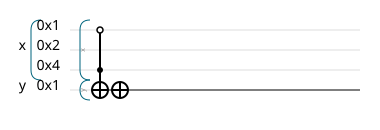

In [4]:
# Draw a circuit of an example clause f(x) = x₀ ∨ ¬x₂
num_inputs, clause = 3, [(0, True), (2, False)]

qpu = QPU(num_qubits=num_inputs + 1)
x = Qubits(num_inputs, "x", qpu)
y = Qubits(1, "y", qpu)
clause_evaluator = EvaluateClause()
clause_evaluator.compute(x, y, clause)
qpu.nop(repeat=12)
qpu.draw()

## 4. Evaluate a SAT formula

Finally, we can implement the evaluation logic of a SAT formula. We will create another Qubrick `EvaluateFormula` to do this, and focus on implementing its `_compute` method. This method will take three arguments: the input and output registers `x` and `y` and the description of the SAT formula as a list of clauses (each clause, in turn, being a list of tuples, same as in earlier code).

First, we need to allocate auxiliary qubits, one per clause, to store the clause evaluation results in them. We will only use them within the `_compute` method of our new Qubrick and release them at the end of the method. We can do that using the `alloc_temp_qreg` method of the Qubrick class:

```python
        a = self.alloc_temp_qreg(num_clauses, "a", release_after_compute=True)
```

Notice that when we allocate qubits using this syntax, we don't need to specify the QPU they belong to. When a Qubrick instance is created, it either requires a QPU instance to be passed as an argument explicitly or deduces it from other arguments. In this case, the QPU instance will be deduced from `Qubits` `x` and `y`.

Next, we evaluate each clause, storing the results in these auxiliary qubits. We can do that by creating one instance of `EvaluateClause` Qubrick and using it for all clauses (with different arguments, of course):

```python
        clause_evaluator = EvaluateClause()
        for ind, clause in enumerate(clauses):
            clause_evaluator.compute(x, a[ind], clause)
```

Once we've done that, we can evaluate the entire formula using our AND implementation - a multi-controlled $X$ gate:

```python
        y.x(cond=a)
```

As the last step of function evaluation, we need to uncompute the clause evaluation to return the auxiliary qubits to the $|0\rangle$ state. 
To uncompute a computation done by the `compute` method of a Qubrick, we need to just call the `uncompute` method of the same Qubrick instance. 
Notice that we don't need to pass the arguments to the `uncompute` method: a call to `uncompute` will reverse the computation done by the last call to `compute` of that Qubrick instance.
This means that we don't have to keep track of the order in which we computed the clauses to uncompute them; we just need to call `uncompute` as many times as we called `compute`.

```python
        for _ in range(num_clauses):
            clause_evaluator.uncompute()
```

After the uncomputation is complete, the auxiliary qubits will be released automatically.

In [5]:
# A classical function that evaluates a SAT formula.
# The formula is an array of clauses in the format described on the previous step.
def f_evaluate_formula(args: list[bool], clauses: list[list[tuple[int, bool]]]) -> bool:
    for clause in clauses:
        if not f_evaluate_clause(args, clause):
            return False
    return True


# Define a Qubrick that evaluates a SAT formula.
class EvaluateFormula(Qubrick):
    'Qubrick that evaluates a SAT formula'
    def _compute(self, x: Qubits, y: Qubits, clauses: list[list[tuple[int, bool]]]) -> None:
        num_clauses = len(clauses)
        # Allocate auxiliary qubits for clause evaluation
        a = self.alloc_temp_qreg(num_clauses, "a", release_after_compute=True)

        clause_evaluator = EvaluateClause()

        # Evaluate clauses and store results in corresponding auxiliary qubits
        for ind, clause in enumerate(clauses):
            clause_evaluator.compute(x, a[ind], clause)

        # Evaluate the formula as the AND of auxiliary qubits
        y.x(cond=a)

        # Uncompute clauses evaluation
        for _ in range(num_clauses):
            clause_evaluator.uncompute()


# Run the tests using test_reversible_function from an earlier cell
formula_evaluator = EvaluateFormula()
for num_inputs, clauses in [
      (1, [[(0, True)], [(0, False)]]), # 0 solutions
      (1, [[(0, False)]]),              # 1 solution
      (2, [[(0, True)], [(1, True)]]),  # 1 solution
      (2, [[(0, False), (1, False)], [(0, True), (1, True)]]), # 2 solutions
      (2, [[(0, False), (1, False)]]),  # 3 solutions
      (3, [[(2, False), (1, True)], [(2, True), (1, False)]]), # 4 solutions
    ]:
    func = partial(f_evaluate_formula, clauses=clauses)
    q_func = partial(formula_evaluator.compute, clauses=clauses)
    test_reversible_function(num_inputs, num_inputs + len(clauses) + 1, func, q_func)
print("SAT formula evaluation tests passed")

SAT formula evaluation tests passed


When we draw a circuit diagram of the code that uses nested Qubricks, it can be convenient to highlight the different Qubricks on the diagram. We can do that by setting the argument `show_qubricks` of the QPU `draw` method to `True`.

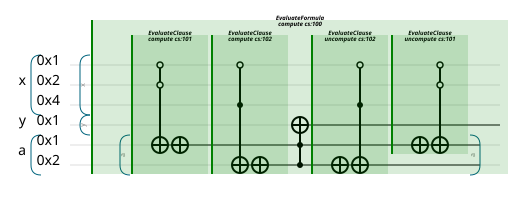

In [6]:
# Draw a circuit of an example SAT formula f(x) = (x₀ ∨ x₁) ∧ (x₀ ∨ ¬x₂)
num_inputs, clauses = 3, [[(0, True), (1, True)], [(0, True), (2, False)]]

qpu = QPU(num_qubits=6)
x = Qubits(num_inputs, "x", qpu)
y = Qubits(1, "y", qpu)
formula_evaluator = EvaluateFormula()
formula_evaluator.compute(x, y, clauses)
qpu.draw(show_qubricks=True)

## 5. Grover's search

With the marking oracle implemented and tested, we now can now write the complete Grover's search for solving SAT problems.
We can implement it as a regular Python code, but in this tutorial we'll wrap the code in another Qubrick to showcase one more tool of working with Qubricks - returning a classical value from the code.

The `_compute` method of `GroversSearchSATProblem` Qubrick will take only classical arguments: the number of input variables, the description of the SAT formula as a list of clauses, and the number of Grover iterations to run before measuring the final result. The lack of quantum arguments means that the Qubrick cannot deduce the QPU to use when allocating new qubits, so we'll have to pass a QPU instance to the constructor when creating a new instance of this Qubrick.

Most of the code in the body of the `_compute` method uses Workbench constructs we've seen before: we allocate two qubit registers, the input register `x` and the `minus` qubit used in phase kickback, and prepare them in the initial state by applying $X$ and $H$ gates. Then, we run the given number of Grover iterations, applying the oracle followed by a reflection about the mean on each iteration.

We can implement the reflection about the $|0\rangle$ state (up to a global phase) easily using the `reflect` method which applies a relative phase to one selected basis state. By default, this method multiplies the $|1...1\rangle$ state by $-1$, leaving other basis states unchanged. We can multiply the $|0\rangle$ state by $-1$ using the negation of the register `x`:

```python
    (~x).reflect()
```

After the iterations are done, we measure the qubits and return the result as the answer from the algorithm. However, the Qubricks infrastructure assumes that the `compute` method doesn't have a return value, so we cannot simply return the measurement result. Instead, we need to use the method `set_classical_result` to set a return value and associate it with the given name:

```python
    self.set_classical_result(res, "result")
```

After we call the `compute` method of the Qubrick, we can then extract the return value using the method `get_classical_result`:

```python
grovers_search = GroversSearchSATProblem(qc=qpu)
grovers_search.compute(num_inputs, clauses, 1)
res = grovers_search.get_classical_result("result")
```

Notice that in the following code snippet we use the default QPU to run the code, while in the tests in the previous sections of this tutorial we used the `>>bit-sim>>` filter. Since we pass the QPU instance to all the Qubricks involved in the computation, it's easy to switch between different QPUs.

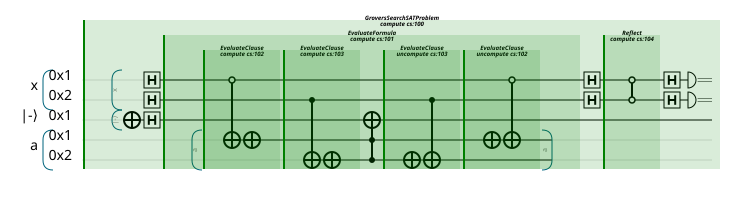

Success rate: 100.0%


In [ ]:
class GroversSearchSATProblem(Qubrick):
    '''Qubrick to solve the SAT problem for the given formula using the given iteration count.'''

    def _compute(self, num_inputs: int, clauses: list[list[tuple[int, bool]]], num_iterations: int) -> None:
        self.qc.reset(num_inputs + len(clauses) + 1)
        oracle = EvaluateFormula()

        x = self.alloc_temp_qreg(num_inputs, "x")
        minus = self.alloc_temp_qreg(1, "|-⟩")

        # Prepare the phase kickback qubit in the |-⟩ state
        minus.x()
        minus.had()

        # Mean state preparation
        x.had()

        for _ in range(num_iterations):
            # Oracle call
            oracle.compute(x, minus, clauses)

            # Reflection about the mean
            x.had()
            (~x).reflect()
            x.had()
        
        # Measure
        res = x.read()
        self.set_classical_result(res, "result")


# Solve an example SAT problem f(x) = (x₀) ∧ (¬x₁) (to get 100% expected success rate)
num_inputs, clauses = 2, [[(0, True)], [(1, False)]]

qpu = QPU(num_qubits=num_inputs + len(clauses) + 1)

# Create the Qubrick and specify the QPU it runs on
grovers_search = GroversSearchSATProblem(qc=qpu)

num_runs = 100
num_correct = 0
correct = 1   # Binary 10, with the least significant bit stored first
for run in range(num_runs):
    grovers_search.compute(num_inputs, clauses, 1)
    if run == 0:
        qpu.draw(show_qubricks=True)
    res = grovers_search.get_classical_result("result")
    if res == correct:
        num_correct += 1

print(f"Success rate: {num_correct * 100 / num_runs}%")

## Conclusion

In this tutorial, we implemented Grover's search for solving SAT problems and tested our program using Workbench.

In the [final part of this tutorial](satsolver_qre.ipynb), we will analyze the performance of our program using QRE Analyzer.